In [1]:
%reload_ext autoreload
%autoreload 2

import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["HDF5_USE_FILE_LOCKING"]= "FALSE"
    
from scipy.constants import mu_0
import MaNTA

from Objective2 import make_objective


import jax
import jax.numpy as jnp
import equinox as eqx 
import yancc

from yancc_wrapper2 import yancc_data

import desc
from desc import set_device
set_device("gpu")
import desc.io
from desc.equilibrium import Equilibrium
from desc.geometry import FourierRZToroidalSurface
from desc.grid import Grid, LinearGrid
from desc.objectives import (
    AspectRatio,
    FixBoundaryR,
    FixBoundaryZ,
    FixCurrent,
    FixPsi,
    ForceBalance,
    LinearObjectiveFromUser,
    ObjectiveFunction,
    ObjectiveFromUser,
    RotationalTransform,
    Volume,
)
from desc.profiles import SplineProfile
import matplotlib.pyplot as plt


Registering cpu implementation for operation get_solution
Registering gpu implementation for operation get_solution
Registering cpu implementation for operation get_adjoint_gradients
Registering gpu implementation for operation get_adjoint_gradients
Registering cpu implementation for operation run
Registering cpu implementation for operation run_ss
Using cache directory: /global/cfs/cdirs/mp217/eatocco/__pycache__
[CudaDevice(id=0), CudaDevice(id=1), CudaDevice(id=2), CudaDevice(id=3)]


/global/cfs/cdirs/mp217/eatocco/DESC/desc/__init__.py:151: UserWarning: CUDA_VISIBLE_DEVICES= did not match any physical GPU (id=['0', '1', '2', '3']), falling back to CPU
  warnings.warn(


In [5]:
from Stellarator2 import StellaratorTransport

fname = "stellarator_opt"

eq_name = "eq"

st_config = {
    "SourceCenter": 0.1,
    "SourceHeight": 40.0,
    "SourceWidth": 0.8,
    "EdgeTemperature":0.25,
    "EdgeDensity": 0.0,
    "n0": 1.0,
}

# st_config = {
#     "SourceCenter": 0.2,
#     "SourceHeight": 1000.0,
#     "SourceWidth": 0.8,
#     "EdgeTemperature":0.5,
#     "EdgeDensity": 0.0,
#     "n0": 0.5,
# }

rho_upper = 1.0
rtol = 1e-2
atol = 1e-3

# # %%
solver_config = {
    "OutputFilename": "stellarator_opt",
    "Polynomial_degree": 3,
    "Grid_size": 6,
    "tau": 1.0, 
    "Lower_boundary": 0.0,
    "Upper_boundary": rho_upper,
    "Relative_tolerance": rtol,
    "Absolute_tolerance": [atol],
    "delta_t": 1e-1,
    "initialTimestep": 1e-6,
    "MinStepSize": 1e-9, 
    "SteadyStateTolerance": 1e-4,
    "restart": False,
    "solveAdjoint": True, 
    "zeroFlux": True,
}


config = {
    "Stellarator": st_config,
    "Solver": solver_config,
}

points =  MaNTA.getNodes(solver_config["Lower_boundary"], solver_config["Upper_boundary"], solver_config["Grid_size"], solver_config["Polynomial_degree"])


yancc_rho = jnp.array(points)
yancc_ntheta = 17
yancc_nzeta = 33

yancc_res = {"na":55,"nx":5}

# to allow maximum flexibility to match manta, we use a spline with the same control points as manta \
# + axis and lcfs
# initial pressure is all zeros, can change this if desired

pressure_rho = jnp.concatenate([jnp.zeros(1), yancc_rho, jnp.ones(1)])
desc_pressure = SplineProfile(jnp.zeros_like(pressure_rho), pressure_rho)
print(pressure_rho)
eq = desc.examples.get("ESTELL")
surf = eq.get_surface_at(rho=1)
# eq.change_resolution(M=4, N=4,L_grid=len(points), M_grid=4, N_grid=4)# 
eq = Equilibrium(M=8, N=8, Psi=0.5, surface=surf, pressure=desc_pressure)
eq = eq.solve(x_scale="ess")[0]

# eq = desc.io.load("eq_self_consistent_pressure.h5")
# desc_pressure = eq.get_profile('p')
eq_init = eq.copy()

V0 = eq.compute("V")["V"]
# yancc_wrapper = yancc_data.from_eq(points, grid = yancc_grid,rho = yancc_rho, Density=Density, eq=eq_init, nt = yancc_ntheta, nz = yancc_nzeta)
yancc_wrapper = yancc_data.from_eq(points, eq=eq_init, nt = yancc_ntheta, nz = yancc_nzeta, **yancc_res)

[0.         0.00634337 0.05144305 0.11522362 0.16032329 0.17301004
 0.21810971 0.28189029 0.32698996 0.33967671 0.38477638 0.44855695
 0.49365663 0.50634337 0.55144305 0.61522362 0.66032329 0.67301004
 0.71810971 0.78189029 0.82698996 0.83967671 0.88477638 0.94855695
 0.99365663 1.        ]
Building objective: force
Precomputing transforms
Building objective: lcfs R
Building objective: lcfs Z
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed current
Building objective: fixed sheet current
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Number of parameters: 856
Number of objectives: 5346

Starting optimization
Using method: lsq-exact
Optimization terminated successfully.
`ftol` condition satisfied. (ftol=1.00e-02)
         Current function value: 7.535e-08
         Total delta_x: 3.111e-01
       

configuring
Successfully created StellaratorTransport object


Total HDG degrees of freedom 79
Configuration done.


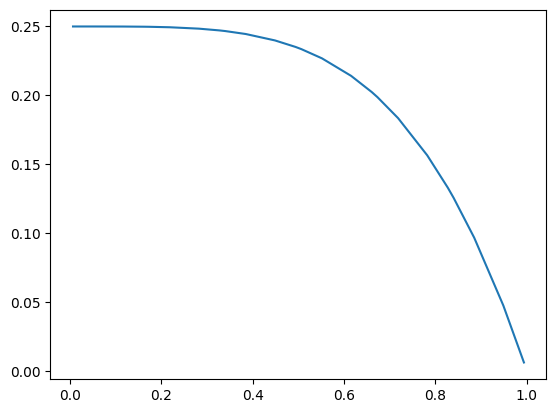

In [6]:


st = StellaratorTransport(config, yancc_wrapper=yancc_wrapper)
plt.plot(points, 2./3. * st.InitialValue(0, points) / yancc_wrapper.Vp)

In [7]:
st.run()

Setting initial conditions
Residual norm at t = 0: 0
Residual norm at t = 0: 0
Residual norm at t = 0: 0
Residual norm at t = 0: 0.306359


Number of Residual Evaluations due to IDACalcIC 3


Residual norm at t = 0: 0.23997
Residual norm at t = 1e-06: 0
Residual norm at t = 1e-06: 0.0307212
Residual norm at t = 2e-06: 8.67526e-06
Residual norm at t = 4e-06: 0.000104466
Residual norm at t = 8e-06: 5.91418e-05
Residual norm at t = 1.6e-05: 0.000669036
Residual norm at t = 3.2e-05: 0.000395998
Residual norm at t = 6.4e-05: 0.000430731
Residual norm at t = 0.000128: 0.00757627
Residual norm at t = 0.000128: 0.0497142
Residual norm at t = 0.000256: 1.69889e-05
Residual norm at t = 0.000256: 0.300018
Residual norm at t = 0.000384: 0.000311315
Residual norm at t = 0.000512: 0.288738
Residual norm at t = 0.00064: 0.308052
Residual norm at t = 0.000896: 0.224575
Residual norm at t = 0.000896: 0.444003
Residual norm at t = 0.001152: 0.105137
Residual norm at t = 0.001152: 0.943544
Residual norm at t = 0.001408: 0.00412416
Residual norm at t = 0.001664: 0.333504
Residual norm at t = 0.00192: 0.300643
Residual norm at t = 0.002176: 0.233855
Residual norm at t = 0.002176: 0.151303
Resid

Writing output at 0.1 ( 59 timesteps )


Residual norm at t = 0.1: 0.102327
Residual norm at t = 0.123264: 0.00154362


...

Writing output at 0.4 ( 69 timesteps )


Residual norm at t = 0.4: 0.0180577


 dy/dt norm inferred from lambdas is 0.372782
Steady State achieved at time t = 0.4
Total Number of Timesteps             :69
Total Number of Residual Evaluations  :129
Total Number of Jacobian Computations :20
Computing adjoints


INFO: Computing adjoints for 5722 parameters
Successfully computed dgdp
5722
24


Done.


Initializing yancc wrapper
Flux norm : 146419.5551768456
yancc_wrapper initialized successfully with resolution na=55, nx=5.
configuring
Successfully created StellaratorTransport object


Total HDG degrees of freedom 79
Configuration done.
Setting initial conditions
Residual norm at t = 0: 0
Residual norm at t = 0: 0
Residual norm at t = 0: 0
Residual norm at t = 0: 0.0153563


Number of Residual Evaluations due to IDACalcIC 3


Residual norm at t = 0: 0.0254643
Residual norm at t = 1e-06: 0
Residual norm at t = 2e-06: 2.11931e-06
Residual norm at t = 4e-06: 3.13293e-08
Residual norm at t = 8e-06: 4.20103e-08
Residual norm at t = 1.6e-05: 3.71828e-07
Residual norm at t = 3.2e-05: 5.93973e-07
Residual norm at t = 6.4e-05: 1.66219e-06
Residual norm at t = 0.000128: 6.33194e-06
Residual norm at t = 0.000256: 3.51528e-06
Residual norm at t = 0.000512: 2.11653e-06
Residual norm at t = 0.001024: 4.32718e-06
Residual norm at t = 0.002048: 7.31208e-06
Residual norm at t = 0.004096: 1.8846e-05
Residual norm at t = 0.008192: 7.40701e-05
Residual norm at t = 0.016384: 0.000270198


Writing output at 0.01 ( 15 timesteps )


...

 dy/dt norm inferred from lambdas is 1.99216
Writing output at 0.09 ( 22 timesteps )


Residual norm at t = 0.09: 0.0338773


 dy/dt norm inferred from lambdas is 0.903962
Steady State achieved at time t = 0.09
Total Number of Timesteps             :22
Total Number of Residual Evaluations  :38
Total Number of Jacobian Computations :17
Computing adjoints


INFO: Computing adjoints for 5722 parameters
Successfully computed dgdp
5722
24


Done.
[35345.27656748 35323.19061238 35245.72920962 35118.26604554
 35070.14249938 34823.79818895 34281.13713768 33716.87171957
 33530.71434691 32733.07296182 31254.86198477 29924.86920233
 29511.25250231 27860.37845115 25088.29036255 22814.82268907
 22135.9557579  19559.06046145 15561.50396969 12517.32064848
 11625.39059674  8419.72164922  3707.89851814   436.40853654]
Building objective: force
Precomputing transforms
Timer: Precomputing transforms = 98.9 ms
Timer: Objective build = 113 ms
Building objective: lcfs R
Building objective: lcfs Z
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed current
Building objective: fixed sheet current
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Timer: Objective build = 160 ms
Timer: LinearConstraintProjection build = 131 ms
Number of parameters: 856
Numbe

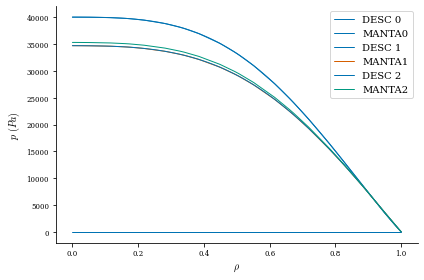

In [8]:
from desc.plotting import plot_1d
from desc.equilibrium import EquilibriaFamily

solver_config = {
    "OutputFilename": fname,
    "Polynomial_degree": 3,
    "Grid_size": 6,
    "tau": 1.0, 
    "Lower_boundary": 0.0,
    "Upper_boundary": rho_upper,
    "Relative_tolerance": rtol,
    "Absolute_tolerance": [atol],
    "delta_t": 1e-2,
    "initialTimestep": 1e-6,
    "MinStepSize": 1e-10,
    "restart": True,
    "solveAdjoint": True, 
    "zeroFlux": True,
    "SteadyStateTolerance": 1e-4,
}

config = {
    "Stellarator": st_config,
    "Solver": solver_config,
}

fig, ax = plt.subplots()

eq2 = eq.copy()
fam2 = EquilibriaFamily(eq2)
niters = 3
for k in range(niters):
    eq2 = eq2.copy()

    fig, ax = plot_1d(eq2, "pressure", label="DESC " + str(k), ax=ax)

    yancc_wrapper = yancc_data.from_eq(points, eq=eq2, nt = yancc_ntheta, nz = yancc_nzeta, **yancc_res)
    pressure_rho = jnp.concatenate([jnp.zeros(1), yancc_rho, jnp.ones(1)])
    st = StellaratorTransport(config, yancc_wrapper=yancc_wrapper)
    st.run()
    
    pi = st.getPressure()
    
    print(pi)
    pi_manta = jnp.concatenate([jnp.array([pi[0]]), pi, jnp.zeros(1)])
    ax.plot(pressure_rho, pi_manta, label="MANTA" + str(k))
    eq2.pressure = SplineProfile(pi_manta, pressure_rho)
    # fit the current profile to a power series, with c_0=c_1=0
    # XX = np.fliplr(np.vander(rho, eq2.L + 1)[:, :-2])
    # eq2.c_l = np.pad(np.linalg.lstsq(XX, current, rcond=None)[0], (2, 0))
    # re-solve the equilibrium
    eq2, _ = eq2.solve(objective="force", optimizer="lsq-exact", verbose=3)
    fam2.append(eq2)

eq_self_consistent = eq2.copy()

ax.legend()

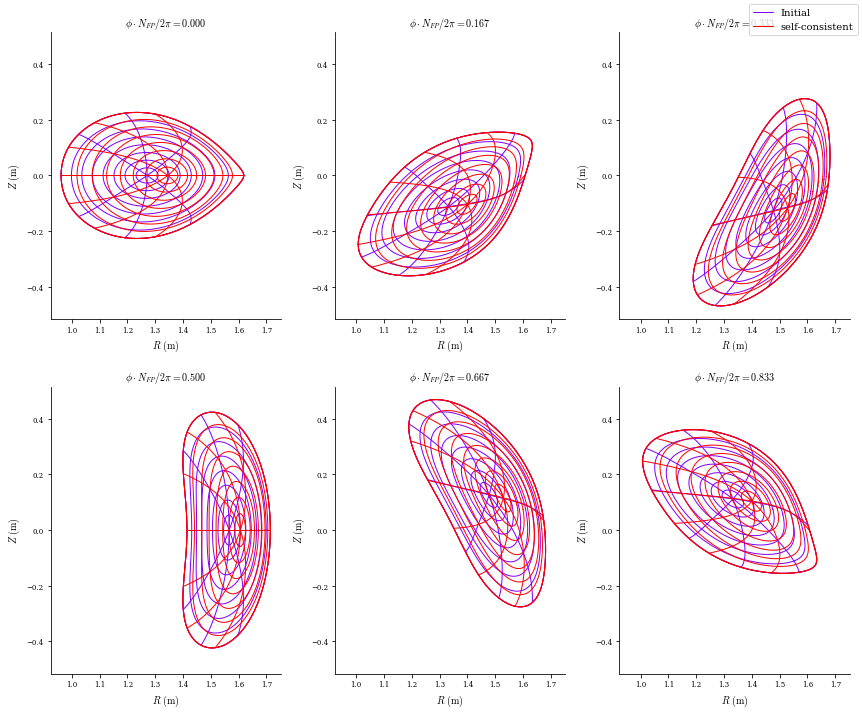

In [9]:
from desc.plotting import plot_comparison

plot_comparison(
    eqs=[eq_init, eq2], labels=["Initial", "self-consistent"]
);

In [10]:
eq = eq2.copy()


In [11]:
solver_config = {
    "OutputFilename": fname,
    "Polynomial_degree": 3,
    "Grid_size": 6,
    "tau": 1.0, 
    "Lower_boundary": 0.0,
    "Upper_boundary": rho_upper,
    "Relative_tolerance": rtol,
    "Absolute_tolerance": [atol],
    "delta_t": 0.1,
    "initialTimestep": 1e-4,
    "MinStepSize": 1e-10,
    "restart": True,
    "solveAdjoint": True, 
    "zeroFlux": True,
    "SteadyStateTolerance": 1e-4,
}
config = {
    "Stellarator": st_config,
    "Solver": solver_config,
}

manta_objective = make_objective(config, yancc_res=yancc_res)

# def manta_yancc_fun(fields, grid, Vprime):

#     stored_energy, pressure = Objective(fields, grid, Vprime) 

#     return stored_energy, pressure

def objective_from_user_fun(grid, data):
  # note: don't change the signature to this function
    yancc_dat = {
        "B_sup_t": data["B^theta"],
        "B_sup_z": data["B^zeta"],
        "B_sub_t": data["B_theta"],
        "B_sub_z": data["B_zeta"],
        "Bmag": data["|B|"],
        "dBdt": data["|B|_t"],
        "dBdz": data["|B|_z"],
        "sqrtg": data["sqrt(g)"],
    }

    yancc_dat = {
        key: grid.meshgrid_reshape(val, "rtz") for key, val in yancc_dat.items()
    }

    yancc_dat["Psi"] = grid.compress(
        data["Psi"] / grid.nodes[:, 0] ** 2, surface_label="rho"
    )
    yancc_dat["a_minor"] = jnp.full(grid.num_rho, data["a"])
    yancc_dat["R_major"] = jnp.full(grid.num_rho, data["R0"])
    yancc_dat["iota"] = grid.compress(data["iota"], surface_label="rho")
    yancc_dat["rho"] = grid.compress(grid.nodes[:, 0], surface_label="rho")

    V = grid.compress(data['V(r)'])
    V_r = grid.compress(data['V_r(r)'])
    V_rr = grid.compress(data['V_rr(r)'])
    Vp = V_r/V[-1]
    Vpp = V_rr/V[-1]
    
    fields = jax.vmap(lambda d: yancc.field.Field(**d, NFP=grid.NFP))(yancc_dat)

    desc_pressure = grid.compress(data["p"], surface_label="rho")
    
    stored_energy, manta_pressure = manta_objective((fields, Vp, Vpp), grid)
    print("------------ STORED ENERGY ----------------")
    print(stored_energy)
    print("-------------------------------------------")
    
    pressure_error = manta_pressure - desc_pressure # not sure if the sign makes the difference here

    print("------------TOTAL PRESSURE ERROR-----------")
    print(pressure_error)
    print("-------------------------------------------")

    # optimization is easiest for least squares objectives, so instead of maximizing
    # stored energy we minimize 1/stored_energy^2 (the squaring happens later)
    return 1/stored_energy

yancc_desc_grid = yancc_wrapper.grid

# domain_boundary_rho = rho_from_normalized_volume(0.9)
domain_boundary_rho = 1.0
def pressure_constraint_fun(params):
    # function to fix dp/dr=0 at axis and p=0 at edge
    # can modify this for other BC (eg fix p at rho=0.8)
    p_l = params["p_l"]
    dp0 = desc_pressure(Grid(jnp.zeros((1, 3)), jitable=True), p_l, dr=1)
    p1 = desc_pressure(Grid(jnp.zeros((1, 3)).at[0, 0].set(domain_boundary_rho), jitable=True), p_l)
    return jnp.array([dp0, p1]).squeeze()


pressure_constraint_target = jnp.array([0.0, 0.0])
# pressure_constraint_target = jnp.array([0.0, st.getPressure([0.9])[0]])

In [ ]:

# other objectives are non-dimensionalized, so weights should account for that
# and handle relative weighting, this will likely need trial and error
# pressure_error_weight = jnp.full(yancc_desc_grid.num_rho, 1e-5)
stored_energy_weight = 10.0
objective_from_user_weight = stored_energy_weight#jnp.append(stored_energy_weight)

objectives = [
    # AspectRatio(eq=eq, target=6, weight=10),
    Volume(eq=eq, target=V0, weight=1.0),
    # RotationalTransform(eq=eq, target=0.42, weight=10),
    ObjectiveFromUser(
        objective_from_user_fun,
        eq,
        target=0,
        weight=objective_from_user_weight,
        grid=yancc_desc_grid,
        deriv_mode="fwd", 
        # need this assuming manta only has vjp, if using jvp switch to fwd
    ),
]
constraints = [
    ForceBalance(eq=eq),  # J x B - grad(p) = 0
    FixCurrent(eq=eq),  # fix zero current, eventually should use real bootstrap
    # Volume(eq=eq, target=V0), # fix volume of outer flux surface
    FixPsi(eq=eq),  # fix total magnetic flux
    LinearObjectiveFromUser(
        pressure_constraint_fun, eq, target=pressure_constraint_target
    ),
]

objective = ObjectiveFunction(objectives)
objective.build(use_jit=False)
# print(objective.jac_scaled(objective.x(eq)))
eq, info_out = eq.optimize(
    objective=objective,
    constraints=constraints,
    optimizer="proximal-lsq-exact",
    x_scale="ess",
    maxiter=5,
    ftol=1e-2,  # stopping tolerance on the function value
    xtol=1e-2,  # stopping tolerance on the step size
    gtol=1e-2,  # stopping tolerance on the gradient
    options={
        "initial_trust_radius": 0.1,   
    # #     # "perturb_options": {"order": 2, "verbose": 3},  # use 2nd-order perturbations
    # #     # "solve_options": {
    # #     #     "ftol": 5e-3,
    # #     #     "xtol": 1e-6,
    # #     #     "gtol": 1e-6,
    # #     #     "verbose": 3,
        },  # for equilibrium subproblem
    # },
    verbose=3,
    copy=True,
)

eq_optimized = eq.copy()

Building objective: volume
Precomputing transforms
Building objective: Custom
Flux norm : JitTracer(~float64[])
yancc_wrapper initialized successfully with resolution na=55, nx=5.
configuring
Successfully created StellaratorTransport object
------------ STORED ENERGY ----------------
JitTracer(float32[])
-------------------------------------------
------------TOTAL PRESSURE ERROR-----------
JitTracer(float64[24])
-------------------------------------------
Building objective: force


Total HDG degrees of freedom 79
Configuration done.


Precomputing transforms
Timer: Precomputing transforms = 100 ms
Timer: Objective build = 116 ms
Timer: Objective build = 1.64 ms
Timer: Eq Update LinearConstraintProjection build = 156 ms
Timer: Proximal projection build = 7.53 sec
Building objective: fixed current
Building objective: fixed Psi
Building objective: custom linear
Timer: Objective build = 3.58 sec
Timer: LinearConstraintProjection build = 6.24 sec
Number of parameters: 313
Number of objectives: 2
Timer: Initializing the optimization = 19.6 sec

Starting optimization
Using method: proximal-lsq-exact
Flux norm : 146419.5551768456
yancc_wrapper initialized successfully with resolution na=55, nx=5.
configuring
Successfully created StellaratorTransport object


Total HDG degrees of freedom 79
Configuration done.
Setting initial conditions


In [ ]:
# final self consistency 
fig, ax = plt.subplots()
niters = 2
for k in range(niters):
    eq = eq.copy()

    fig, ax = plot_1d(eq, "pressure", label="DESC " + str(k), ax=ax)

    yancc_wrapper = yancc_data.from_eq(points, eq=eq2, nt = yancc_ntheta, nz = yancc_nzeta)
 
    st = StellaratorTransport(config, yancc_wrapper=yancc_wrapper)
    st.run()
    
    pi = st.getPressure()

    pi_manta = jnp.concatenate([jnp.array([pi[0]]), pi, jnp.zeros(1)])
    ax.plot(pressure_rho, pi_manta, label="MANTA" + str(k))
    eq.pressure = SplineProfile(pi_manta, pressure_rho)
    # fit the current profile to a power series, with c_0=c_1=0
    # XX = np.fliplr(np.vander(rho, eq2.L + 1)[:, :-2])
    # eq2.c_l = np.pad(np.linalg.lstsq(XX, current, rcond=None)[0], (2, 0))
    # re-solve the equilibrium
    eq, _ = eq.solve(objective="force", optimizer="lsq-exact", verbose=3)


ax.legend()
eq_optimized_self_consistent = eq.copy()

In [ ]:
eq_optimized_self_consistent.save(eq_name + "optimized_equilibrium.h5")

In [ ]:
from desc.plotting import plot_comparison

plot_comparison(
    eqs=[eq_init, eq], labels=["Initial", "self-consistent"]
);

In [ ]:
from desc.plotting import plot_boundaries

plot_comparison(
    eqs=[eq_init, eq_optimized, eq], labels=["Initial", "optimized", "self-consistent"]
);

In [ ]:
plot_boundaries(
    eqs=[eq_init, eq_optimized, eq], labels=["Initial", "optimized", "self-consistent"]
);

In [ ]:
from desc.plotting import plot_boozer_surface, plot_boundaries, plot_qs_error
# eq = desc.io.load("../python/eq2optimized_equilibrium.h5")#desc.examples.get("ESTELL")
# plot_boozer_surface(eq_init, fieldlines=8)
plot_boozer_surface(eq, fieldlines=8)
# plot_qs_error(eq_init)
plot_qs_error(eq)